# Customer Churn Analysis

## Business Problem Statement

### Introduction
Customer churn refers to the loss of customers who discontinue using a company's products or services over a given period. In the telecommunications industry, customer retention is a critical factor for maintaining revenue and profitability. Since acquiring new customers is generally more expensive than retaining existing ones, understanding the reasons behind customer churn is essential for business success.

This project focuses on analyzing customer data from a telecom company to identify the factors that influence customer churn. The dataset contains customer demographics, service subscriptions, account information, and churn status.

### Problem Statement
The telecom company is facing customer attrition and wants to understand the characteristics and behaviors of customers who are more likely to leave the company. By identifying the key factors associated with churn, the company can implement effective retention strategies and improve customer satisfaction.

### Objectives
- Analyze customer demographic and service-related data.
- Identify patterns and trends associated with customer churn.
- Determine the most significant factors influencing churn.
- Provide actionable recommendations to reduce customer attrition.
- Support business decision-making through data-driven insights.

### Expected Outcomes
- Identification of high-risk customer segments.
- Understanding of the relationship between customer services and churn.
- Insights into customer retention opportunities.
- Recommendations for improving customer loyalty and reducing revenue loss.

### Dataset Information
The dataset contains information about 7,043 telecom customers and includes:
- Customer demographics (Gender, Senior Citizen, Partner, Dependents)
- Account information (Tenure, Contract Type, Payment Method)
- Services subscribed (Phone Service, Internet Service, Online Security, Tech Support, etc.)
- Customer Churn Status (Yes/No)

### Business Impact
The insights generated from this analysis will help the telecom company:
- Improve customer retention strategies.
- Reduce churn-related revenue losses.
- Enhance customer satisfaction.
- Increase long-term profitability.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv('customerchurn.csv')
df.head(1)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## Data Cleaning

In [4]:
df['TotalCharges']=pd.to_numeric(df['TotalCharges'],errors='coerce')


In [5]:
def cov(value):
  if(value==1):
    return "yes"
  else:
    return "no"

df['SeniorCitizen']=df['SeniorCitizen'].apply(cov)

In [6]:
df[df['tenure']==0]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,no,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,no,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,no,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,no,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,no,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,no,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,no,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,no,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,no,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,no,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [7]:
df['TotalCharges']=df['TotalCharges'].fillna(0)

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df['customerID'].duplicated().sum()

np.int64(0)

In [10]:
group=df.groupby('SeniorCitizen')['Churn'].value_counts().reset_index()

In [11]:
print(group)

  SeniorCitizen Churn  count
0            no    No   4508
1            no   Yes   1393
2           yes    No    666
3           yes   Yes    476


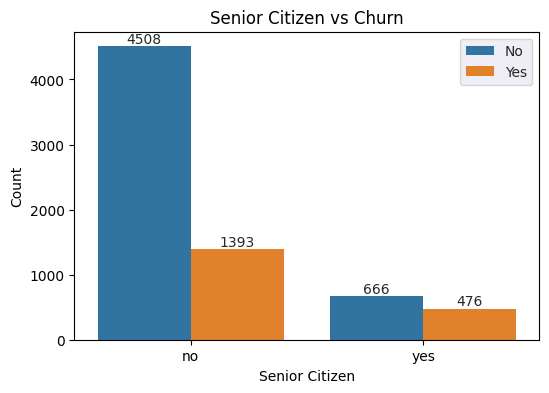

In [12]:
plt.figure(figsize=(6,4))
ax=sns.barplot(x='SeniorCitizen',y='count',hue='Churn',data=group)
plt.title('Senior Citizen vs Churn')
sns.set_style('darkgrid')
sns.set_palette('Set2')
plt.xlabel('Senior Citizen')
plt.ylabel('Count')
plt.legend(loc='upper right')
for container in ax.containers:
  ax.bar_label(container)

plt.show()

SeniorCitizen are more likely to get churn

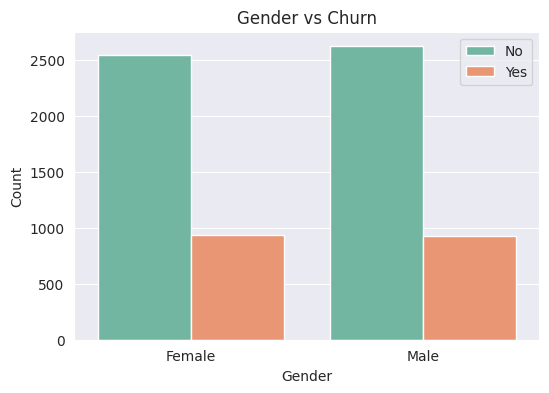

In [13]:
plt.figure(figsize=(6,4))
sns.countplot(x='gender',hue='Churn',data=df)
plt.title('Gender vs Churn')
sns.set_style('darkgrid')
sns.set_palette('Set2')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.legend(loc='upper right')
plt.show()

Customer Churn is almost equally distributed across male and female there is no singificant impact of gender on Customer churn

In [14]:
df.head(1)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,no,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No


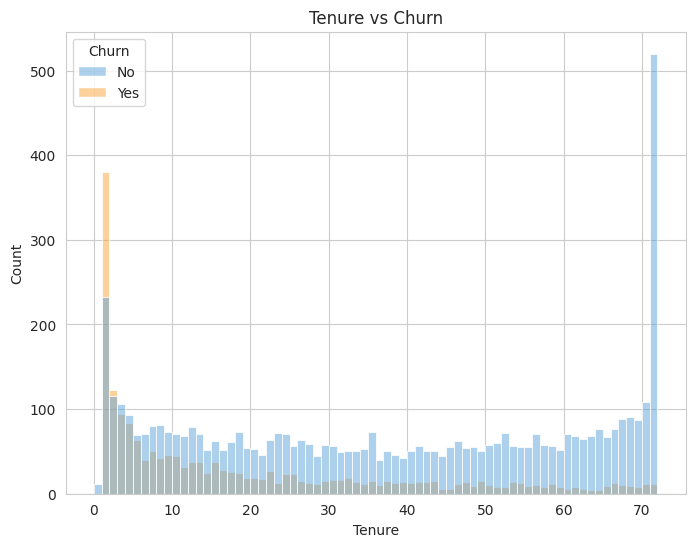

In [30]:
plt.figure(figsize=(8,6))
sns.histplot(x='tenure',bins=72,hue='Churn',data=df,palette={'No':'#5DA5DA', 'Yes':'#FAA43A'})
plt.title('Tenure vs Churn')
plt.xlabel('Tenure')
plt.ylabel('Count')
plt.show()

Most of the customer got churn was from 1st moth,the customer who stayed for more tenure were Mostly not getting churn

## Subplots


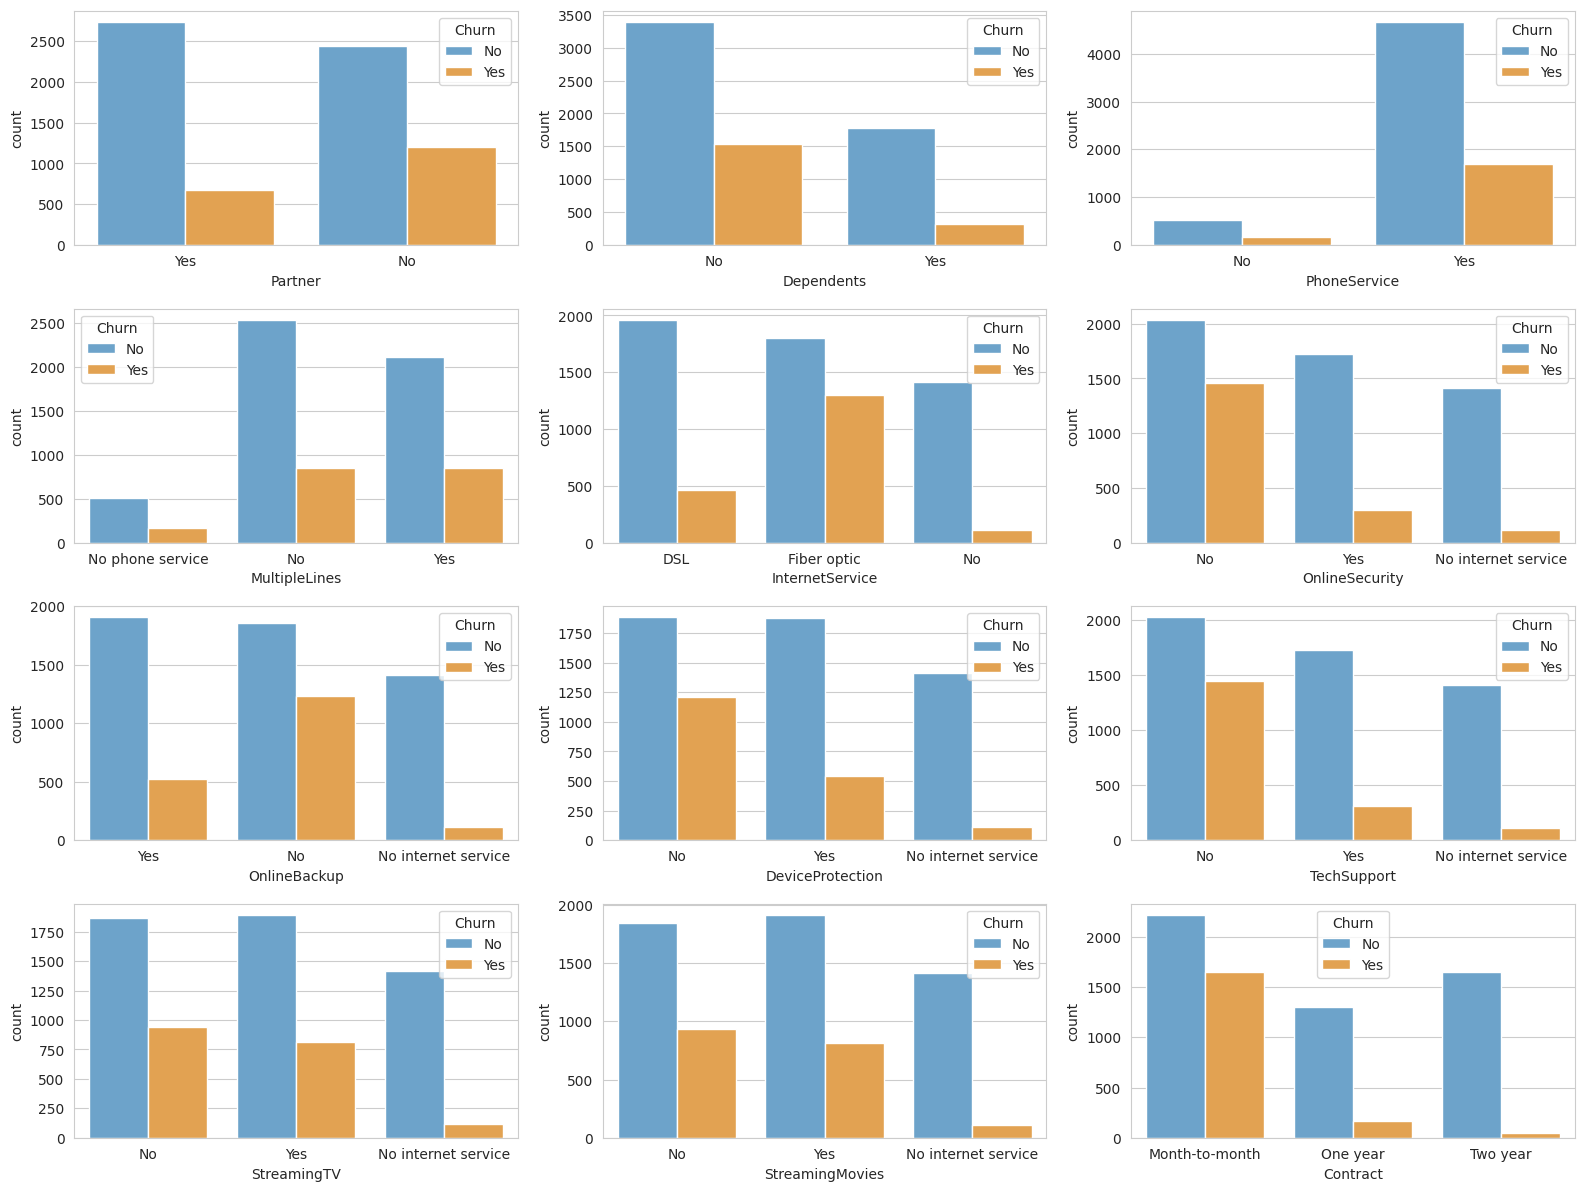

In [43]:
fig,ax=plt.subplots(4,3,figsize=(16,12))

sns.countplot(x='Partner',hue='Churn',data=df,ax=ax[0,0],palette={'No':'#5DA5DA', 'Yes':'#FAA43A'})
sns.countplot(x='Dependents',hue='Churn',data=df,ax=ax[0,1],palette={'No':'#5DA5DA', 'Yes':'#FAA43A'})
sns.countplot(x='PhoneService',hue='Churn',data=df,ax=ax[0,2],palette={'No':'#5DA5DA', 'Yes':'#FAA43A'})
sns.countplot(x='MultipleLines',hue='Churn',data=df,ax=ax[1,0],palette={'No':'#5DA5DA', 'Yes':'#FAA43A'})
sns.countplot(x='InternetService',hue='Churn',data=df,ax=ax[1,1],palette={'No':'#5DA5DA', 'Yes':'#FAA43A'})
sns.countplot(x='OnlineSecurity',hue='Churn',data=df,ax=ax[1,2],palette={'No':'#5DA5DA', 'Yes':'#FAA43A'})
sns.countplot(x='OnlineBackup',hue='Churn',data=df,ax=ax[2,0],palette={'No':'#5DA5DA', 'Yes':'#FAA43A'})
sns.countplot(x='DeviceProtection',hue='Churn',data=df,ax=ax[2,1],palette={'No':'#5DA5DA', 'Yes':'#FAA43A'})
sns.countplot(x='TechSupport',hue='Churn',data=df,ax=ax[2,2],palette={'No':'#5DA5DA', 'Yes':'#FAA43A'})
sns.countplot(x='StreamingTV',hue='Churn',data=df,ax=ax[3,0],palette={'No':'#5DA5DA', 'Yes':'#FAA43A'})
sns.countplot(x='StreamingMovies',hue='Churn',data=df,ax=ax[3,1],palette={'No':'#5DA5DA', 'Yes':'#FAA43A'})
sns.countplot(x='Contract',hue='Churn',data=df,ax=ax[3,2],palette={'No':'#5DA5DA', 'Yes':'#FAA43A'})
plt.tight_layout()
plt.savefig('subplot.jpeg')
plt.show()



# The strongest factors associated with higher churn are:

Month-to-Month Contract
Fiber Optic Internet Service
No Online Security
No Tech Support
No Device Protection
No Online Backup
No Dependents
No Partner
Business Recommendation

## To reduce churn, the telecom company should:

Encourage customers to switch from month-to-month to longer-term contracts.
Promote value-added services such as Online Security, Tech Support, Device Protection, and Online Backup.
Investigate why Fiber Optic customers are leaving at a higher rate and improve service quality or pricing.